# Permutation Feature Importance

Based on Christoph Molnar’s *Interpretable Machine Learning* (feature importance section).

This assignment uses the Iris dataset and asks students to implement permutation feature importance (PFI) from scratch, then apply it to a Perceptron and a Gaussian Naive Bayes classifier using scikit-learn, pandas, and numpy.


## Part A — Read & short answer (10 pts)

(Prereq) Read the section “Permutation Feature Importance” in the Interpretable Machine Learning book (Molnar).

**Answer in this cell (3–6 sentences):**

1. The basic idea of permutation importance.

The basic idea of Permutation Feature Importance is to figure out which features in a dataset is contributing the most to the predictions the model is giving. To find the most important feature, you must go through and permutuate one column at a time and test the error rate of that test to the base error rate from just running it on the data. If the error rate of the permutate dataset is significantly different than the base dataset error rate, that feature is very important to the models prediction. Which ever column produces the highest error rate is considered the most important feature in the dataset.

2. One strength and one limitation of PFI.

One strength about PFI is that it is useful when all of the data is uncorrelated with each other to find what is the most important feature the model uses to deteremine, for example, the sex of a penguin. One limitiation is that PFI doesn’t tell you how the feature influences the prediction, only how much it affects the loss. It can't tell you how much or how the feature affects the results just that it influences it in a higher way than others.


## Part B — Implementation (70 pts)

You must implement a function `permutation_feature_importance(...)` that computes permutation feature importance for a trained model. Requirements:

- Inputs: `model`, `X` (DataFrame or array), `y`, `metric` (callable returning an error-like value, lower is better), `n_repeats=30`, `random_state=None`, `kind='difference'` or `'ratio'`.
- Use the provided test set `X_test`, `y_test` when calling your function.
- Do **not** use `sklearn.inspection.permutation_importance` — implement the permutation loop yourself.

Return a `pandas.DataFrame` with columns: `feature`, `mean_importance`, `std_importance`, `raw_importances`, `e_orig`.

**Hint:** For classification use `metric = lambda y_true, y_pred: 1 - accuracy_score(y_true, y_pred)` so the metric is an error (lower is better).


In [1]:
# Starter code: imports and data split
import numpy as np
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score
from copy import deepcopy

# Load data
iris = load_iris()
X = pd.DataFrame(iris.data, columns=iris.feature_names)
y = iris.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

# Train simple models
per = Perceptron(random_state=0, max_iter=1000)
nb = GaussianNB()

per.fit(X_train, y_train)
nb.fit(X_train, y_train)

print('Train and test shapes:', X_train.shape, X_test.shape)
print('Perceptron test accuracy (baseline):', accuracy_score(y_test, per.predict(X_test)))
print('GaussianNB test accuracy (baseline):', accuracy_score(y_test, nb.predict(X_test)))


Train and test shapes: (105, 4) (45, 4)
Perceptron test accuracy (baseline): 0.8666666666666667
GaussianNB test accuracy (baseline): 0.9111111111111111


In [49]:
# TODO: Implement this function
def permutation_feature_importance(model,X,y,metric,n_repeats=30,random_state=None,kind='difference'):
  original_model_error = metric(y, model.predict(X))
  sum_imp = np.zeros(len(X_test.columns.tolist()), dtype=float)
  sumsq_imp = np.zeros(len(X_test.columns.tolist()), dtype=float)
  for j in range(len(X_test.columns.tolist())):
    for i in range(n_repeats):
      copy_X = X.copy(deep=True)
      column_values = copy_X.iloc[:, j].to_numpy().copy()
      np.random.shuffle(column_values)
      copy_X.iloc[:, j] = column_values
      permuted_model_error = metric(y, model.predict(copy_X))
      if kind == 'difference':
        error_difference = permuted_model_error - original_model_error
        sum_imp[j] += error_difference
        sumsq_imp[j] += error_difference * error_difference
      if kind == 'ratio':
        error_ratio = permuted_model_error / original_model_error
        sum_imp[j] += error_ratio
        sumsq_imp[j] += error_ratio * error_ratio

  mean_imp = sum_imp / n_repeats
  var_imp = (sumsq_imp - n_repeats * mean_imp**2) / (n_repeats - 1)
  std_imp = np.sqrt(np.maximum(var_imp, 0.0))

  results = pd.DataFrame({
        "feature": list(X.columns),
        "mean_importance": mean_imp,
        "std_importance": std_imp,
        "e_orig": original_model_error
    }).sort_values("mean_importance", ascending=False).reset_index(drop=True)
  return results


Perceptron PFI (difference):
              feature  mean_importance  std_importance    e_orig
0  petal length (cm)         0.480889        0.065793  0.133333
1   petal width (cm)         0.177333        0.041753  0.133333
2   sepal width (cm)         0.085333        0.053000  0.133333
3  sepal length (cm)         0.057778        0.052164  0.133333

GaussianNB PFI (difference):
              feature  mean_importance  std_importance    e_orig
0   petal width (cm)         0.379556        0.064880  0.088889
1  petal length (cm)         0.303556        0.051112  0.088889
2  sepal length (cm)        -0.005333        0.020357  0.088889
3   sepal width (cm)        -0.015556        0.019698  0.088889


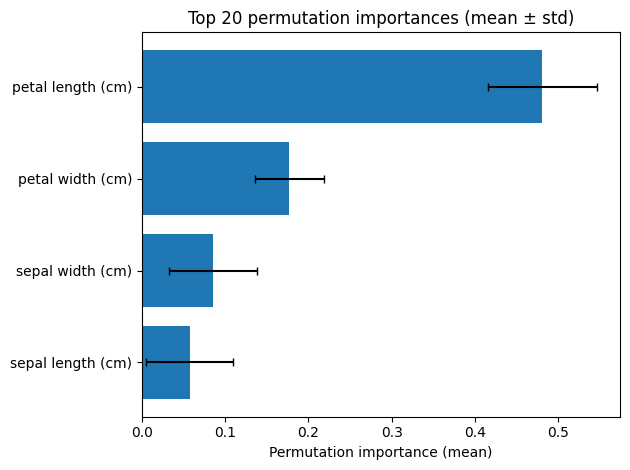

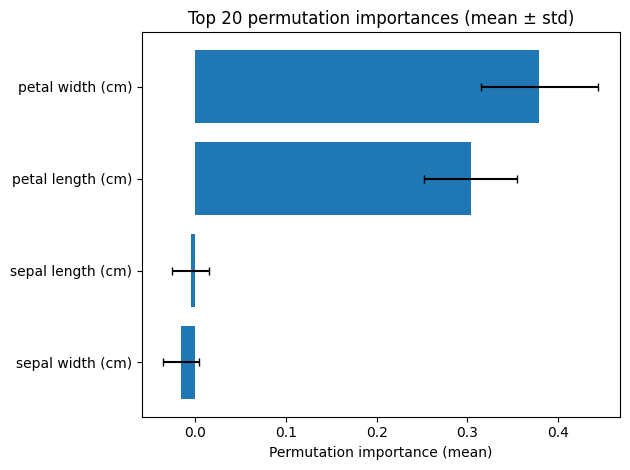

In [52]:
# Experiment: compute PFI using your function (once implemented)
from sklearn.metrics import accuracy_score

# Define error-like metric
metric_error = lambda y_true, y_pred: 1.0 - accuracy_score(y_true, y_pred)

#Example usage (uncomment after implementing permutation_feature_importance)
pfi_per_diff = permutation_feature_importance(per, X_test, y_test, metric=metric_error, n_repeats=50, random_state=0, kind='difference')
pfi_nb_diff = permutation_feature_importance(nb, X_test, y_test, metric=metric_error, n_repeats=50, random_state=0, kind='difference')
print('Perceptron PFI (difference):\n', pfi_per_diff)
print('\nGaussianNB PFI (difference):\n', pfi_nb_diff)

import matplotlib.pyplot as plt

def plot_perm_importance_barh(df, top_n=20):
    d = df.sort_values("mean_importance", ascending=False).head(top_n).iloc[::-1]

    plt.figure()
    plt.barh(d["feature"], d["mean_importance"], xerr=d["std_importance"], capsize=3)
    plt.xlabel("Permutation importance (mean)")
    plt.title(f"Top {top_n} permutation importances (mean ± std)")
    plt.tight_layout()
    plt.show()

plot_perm_importance_barh(pfi_per_diff)

plot_perm_importance_barh(pfi_nb_diff)


## Part C — Experiment questions (20 pts)

1. Do the two models agree on the most important features? (2–4 sentences)
No, the Perceptron Model thinks that the most important feature was the petal length and the Naive Bayes thinks that the most important feature was the petal width. In a sense they both that a part of the petal was the most importnatnt part so it's not too far off from each other.

2. Brief reflection (2–4 sentences) on limitations of PFI and what correlated features do to the estimates.

One limitiation is that most data has columns that are correlated to each other so one of columns is permutated it could drastically change the error rate, but in reality it wouldn't have. For example, there are many differen species of monkey and they can all weight differently according to their species. If we had all the monkeys data in one dataset and scrabbled the weights, it'll give a significantly different error rate cause the monkey's are all different. If we kept the permutation between the species, the error rate might not be so drastic. This is called Conditional Feature Importance(CFI).



## Deliverables

- Notebook `.ipynb` with your implementation and answers.
- Short answers for Part A and Part C.
- Plots/tables and brief reflection.
